# Fire Scar Detection with Prithvi-EO-2.0

This notebook fine-tunes the NASA/IBM Prithvi-EO-2.0-300M geospatial foundation model for burned area segmentation using the HLS Burn Scars dataset and TerraTorch.

**Milestones:**
1. Download and verify dataset
2. Set up environment and validate configuration
3. Fine-tune the model
4. Evaluate on test split
5. Run inference on a new fire event

In [1]:
# === Configuration ===
from pathlib import Path

# Paths
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./output")
CONFIG_PATH = Path("./burn_scars_config.yaml")

# === Mode: QUICK_TEST (True) or FULL_RUN (False) ===
QUICK_TEST = True

if QUICK_TEST:
    MAX_CHIPS = 80
    MAX_EPOCHS = 5
    BATCH_SIZE = 8
else:
    MAX_CHIPS = None
    MAX_EPOCHS = 80
    BATCH_SIZE = 8

LEARNING_RATE = 1e-4
PRECISION = "bf16-mixed"

# Feature flags
RUN_TRAINING = True
RUN_INFERENCE = True
SHOW_VISUALISATIONS = True

print(f"Mode: {'QUICK_TEST' if QUICK_TEST else 'FULL_RUN'}")
print(f"Max chips: {MAX_CHIPS or 'all (804)'}, Epochs: {MAX_EPOCHS}")

Mode: QUICK_TEST
Max chips: 80, Epochs: 5


---
## Milestone 1: Download and Verify Dataset

The HLS Burn Scars dataset contains 804 paired image/label chips (512×512 pixels, 30m resolution) from the continental US. Each image has 6 spectral bands (Blue, Green, Red, NIR Narrow, SWIR1, SWIR2). Labels are binary: 0=unburned, 1=burned, -1=no data.

In [2]:
from modules.data_access import download_dataset, load_splits, verify_dataset, get_chip_paths, verify_chip

dataset_dir = download_dataset(DATA_DIR, max_chips=MAX_CHIPS)
splits = load_splits(dataset_dir, max_chips=MAX_CHIPS)
summary = verify_dataset(dataset_dir, splits)

print(f"Total chips: {summary['total_chips']}")
print(f"Splits: {summary['splits']}")
print(f"Chips verified: {summary['chips_verified']}")
if summary['issues']:
    print(f"Issues: {summary['issues']}")
else:
    print("All verified chips OK.")

Dataset already exists at data/hls_burn_scars


Total chips: 78
Splits: {'train': 40, 'val': 19, 'test': 19}
Chips verified: 15
All verified chips OK.


2026-05-28 01:40:50,026 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,062 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,078 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,113 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,130 - INFO - Found credentials in environment variables.


...

2026-05-28 01:40:50,207 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,228 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,257 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,273 - INFO - Found credentials in environment variables.


2026-05-28 01:40:50,297 - INFO - Found credentials in environment variables.


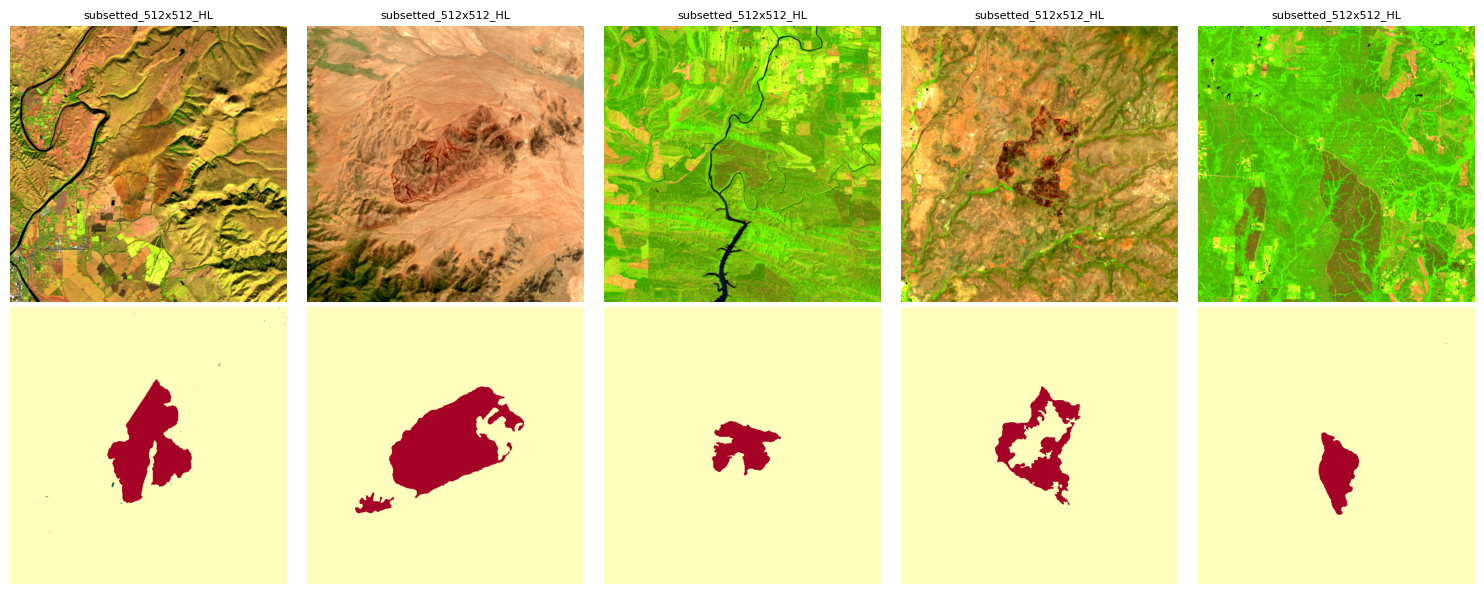

In [4]:
# Visual check: display sample chips
import numpy as np
import rasterio
from modules.visualisation import plot_sample_chips

if SHOW_VISUALISATIONS:
    sample_names = splits['train'][15:21]
    images, masks = [], []
    for name in sample_names:
        img_path, mask_path = get_chip_paths(dataset_dir, name)
        with rasterio.open(img_path) as src:
            images.append(src.read())
        with rasterio.open(mask_path) as src:
            masks.append(src.read(1))
    plot_sample_chips(images, masks, titles=sample_names)

**Validation:** Expect 804 chips total (or ~80 in quick-test mode). Images should be (6, 512, 512) float32. Masks should contain values {-1, 0, 1} with some burned pixels present.

**Stop if:** File count wrong, unexpected shapes, or all masks are class 0.

---
## Milestone 2: Environment Setup and Configuration

Verify GPU availability, generate the TerraTorch config, and validate with a single training step.

In [3]:
from modules.training import check_gpu, generate_config

gpu_info = check_gpu()
print(f"GPU available: {gpu_info['available']}")
if gpu_info['available']:
    print(f"GPU: {gpu_info['name']} ({gpu_info['memory_gb']} GB)")
else:
    print("WARNING: No GPU detected. Training will be very slow on CPU.")

GPU available: True
GPU: NVIDIA L4 (23.7 GB)


In [4]:
# Generate training config
config_path = generate_config(
    dataset_dir=dataset_dir,
    output_path=CONFIG_PATH,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    precision=PRECISION,
)
print(f"Config generated at: {config_path}")

Config written to burn_scars_config.yaml


Config generated at: burn_scars_config.yaml


**Validation:** GPU should be detected (T4 or better). Config file should reference correct paths and hyperparameters.

**Stop if:** No GPU (training will be impractical). Config generation fails.

---
## Milestone 3: Fine-tune the Model

Train the Prithvi-EO-2.0-300M backbone with a UNet decoder for binary burn scar segmentation.

In [5]:
from modules.training import run_training

if RUN_TRAINING:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    return_code = run_training(config_path, output_dir=OUTPUT_DIR)
    if return_code == 0:
        print("Training completed successfully!")
    else:
        print(f"Training failed (return code {return_code}). Check logs above.")
else:
    print("Skipping training (RUN_TRAINING=False). Using existing checkpoint.")

Starting training: /env/bin/python -m terratorch fit -c burn_scars_config.yaml --trainer.default_root_dir output


Seed set to 42


2026-05-28 01:12:53,855 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"


2026-05-28 01:12:54,203 - INFO - HTTP Request: GET https://huggingface.co/api/models/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/xet-read-token/9eb1b1102806593963daa333bcc491b1c6f8562f "HTTP/1.1 200 OK"


2026-05-28 01:13:32,970 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-05-28 01:13:32,970 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-05-28 01:13:32,970 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-05-28 01:13:32,970 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-05-28 01:13:32,970 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-05-28 01:13:32,971 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
/env/lib/python3.12/site-packages/lightning/pytorch/cli.py:734: `SemanticSegmentationTask.configure_optimizers` will be overridden by `MyLightningCLI.configure_optimizers`.
Using bfloat16 Automatic Mixed Precision (AMP)


...

Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━ 67/67 0:01:02 • 0:00:00 1.08it/s v_num: 0.000

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━ 67/67 0:01:02 • 0:00:00 1.08it/s v_num: 0.000


Training completed successfully.


Training completed successfully!


In [6]:
# Plot training curves
from modules.visualisation import plot_training_curves

if SHOW_VISUALISATIONS and RUN_TRAINING:
    # Find the latest lightning log directory
    log_dirs = sorted(OUTPUT_DIR.glob("lightning_logs/version_*"))
    if log_dirs:
        plot_training_curves(log_dirs[-1])
    else:
        print("No training logs found.")

No metrics file found at output/lightning_logs/version_0/metrics.csv


**Validation:**
- Quick test: loss should decrease over 5 epochs. Val IoU > 50% confirms learning.
- Full run: loss plateaus by epoch 30-50. Val IoU > 80%.

**Stop if:** Loss doesn't decrease. Val IoU < 30% (quick) or < 70% (full).

---
## Milestone 4: Test Set Evaluation

Evaluate the best checkpoint on the held-out test split.

In [5]:
from modules.inference import load_model, load_scene, normalise_scene, predict
from modules.evaluation import compute_iou, evaluate_test_set, find_best_worst_chips

# Find best checkpoint
ckpt_dirs = sorted(OUTPUT_DIR.glob("lightning_logs/version_*/checkpoints/*.ckpt"))
if not ckpt_dirs:
    print("No checkpoint found. Run training first.")
else:
    best_ckpt = ckpt_dirs[-1]
    print(f"Loading checkpoint: {best_ckpt}")
    model = load_model(best_ckpt)

    # Run predictions on test split
    predictions, targets = [], []
    for chip_name in splits['test']:
        img_path, mask_path = get_chip_paths(dataset_dir, chip_name)
        if not img_path.exists():
            continue
        data, _ = load_scene(img_path)
        data_norm = normalise_scene(data)
        pred = predict(model, data_norm)
        predictions.append(pred)

        with rasterio.open(mask_path) as src:
            targets.append(src.read(1))

    results = evaluate_test_set(predictions, targets)
    agg = results['aggregate']
    print(f"\nTest Results ({agg['num_chips']} chips):")
    print(f"  IoU (burned):  {agg['iou_burned']:.1%}")
    print(f"  Mean IoU:      {agg['mean_iou']:.1%}")
    print(f"  Precision:     {agg['precision']:.1%}")
    print(f"  Recall:        {agg['recall']:.1%}")
    print(f"  F1:            {agg['f1']:.1%}")

Loading checkpoint: output/lightning_logs/version_0/checkpoints/epoch=4-step=335.ckpt


2026-05-28 01:41:05,720 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"


2026-05-28 01:41:06,157 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed


2026-05-28 01:41:06,157 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed


2026-05-28 01:41:06,158 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed


...

2026-05-28 01:41:08,967 - INFO - Found credentials in environment variables.


2026-05-28 01:41:09,059 - INFO - Found credentials in environment variables.


2026-05-28 01:41:09,122 - INFO - Found credentials in environment variables.


2026-05-28 01:41:09,216 - INFO - Found credentials in environment variables.



Test Results (19 chips):
  IoU (burned):  76.5%
  Mean IoU:      86.0%
  Precision:     89.3%
  Recall:        83.6%
  F1:            86.1%


2026-05-28 01:41:46,671 - INFO - Found credentials in environment variables.


Best predictions:


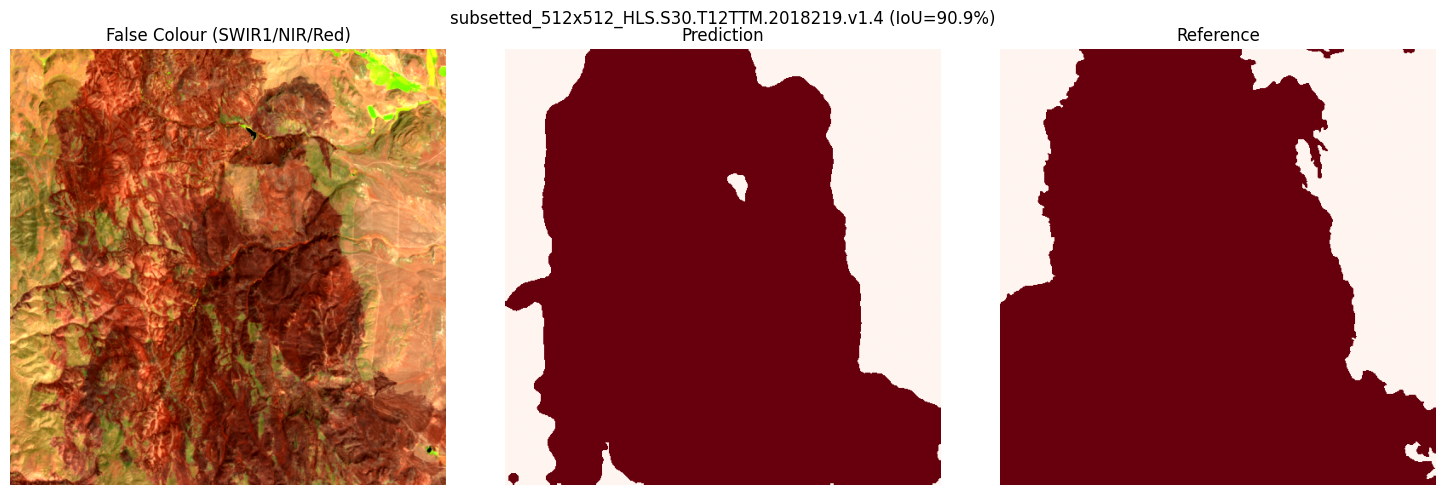

2026-05-28 01:41:46,953 - INFO - Found credentials in environment variables.


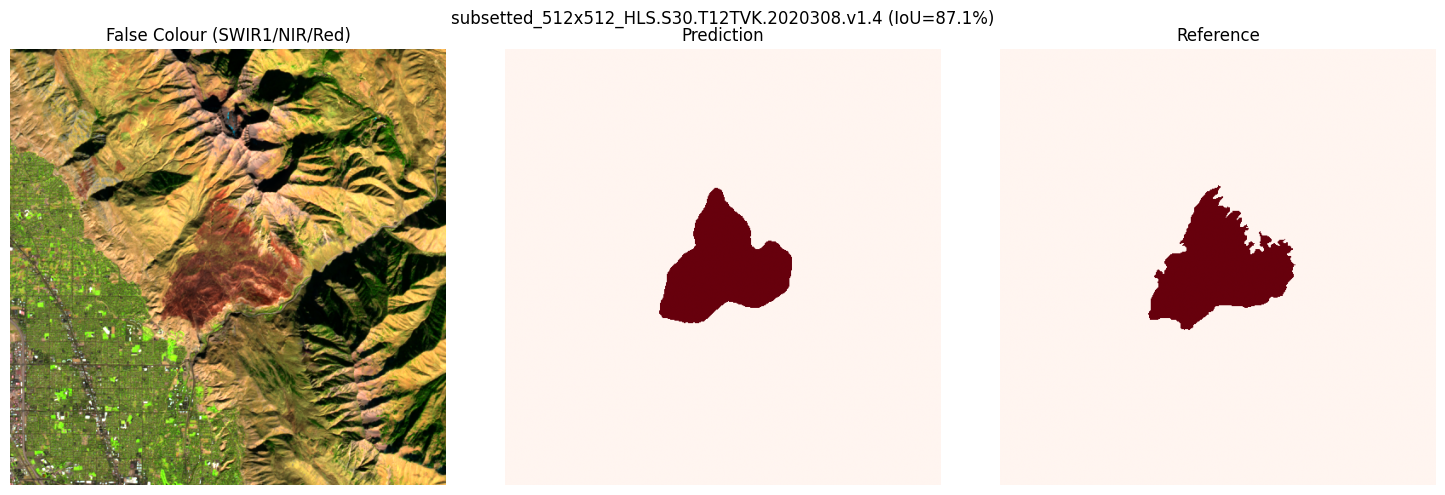

2026-05-28 01:41:47,216 - INFO - Found credentials in environment variables.


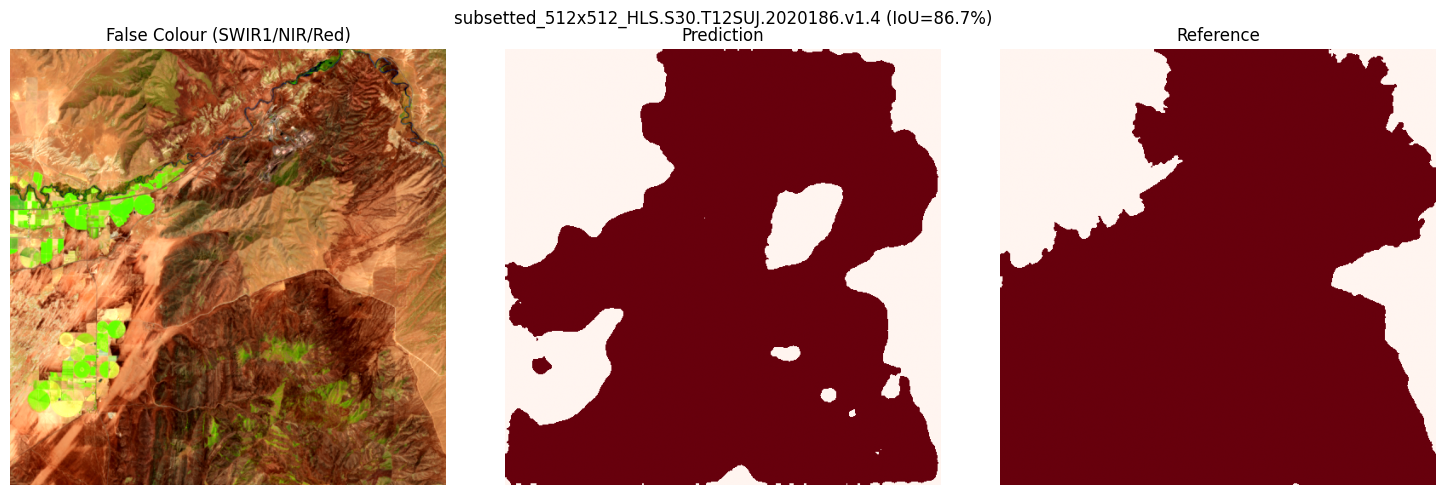

2026-05-28 01:41:47,495 - INFO - Found credentials in environment variables.



Worst predictions:


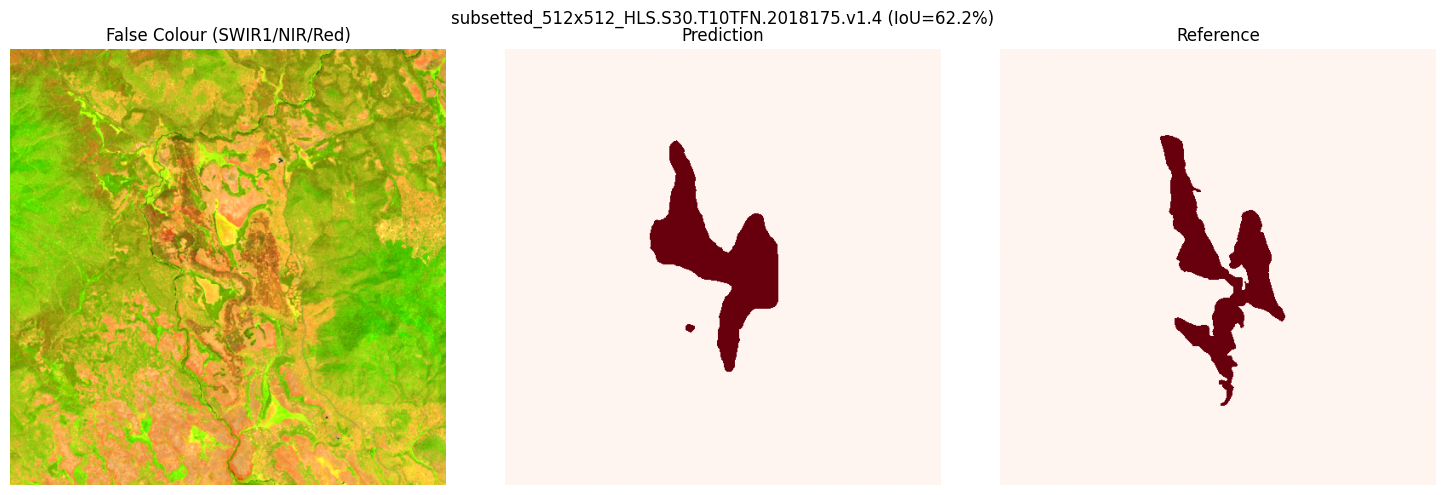

2026-05-28 01:41:47,763 - INFO - Found credentials in environment variables.


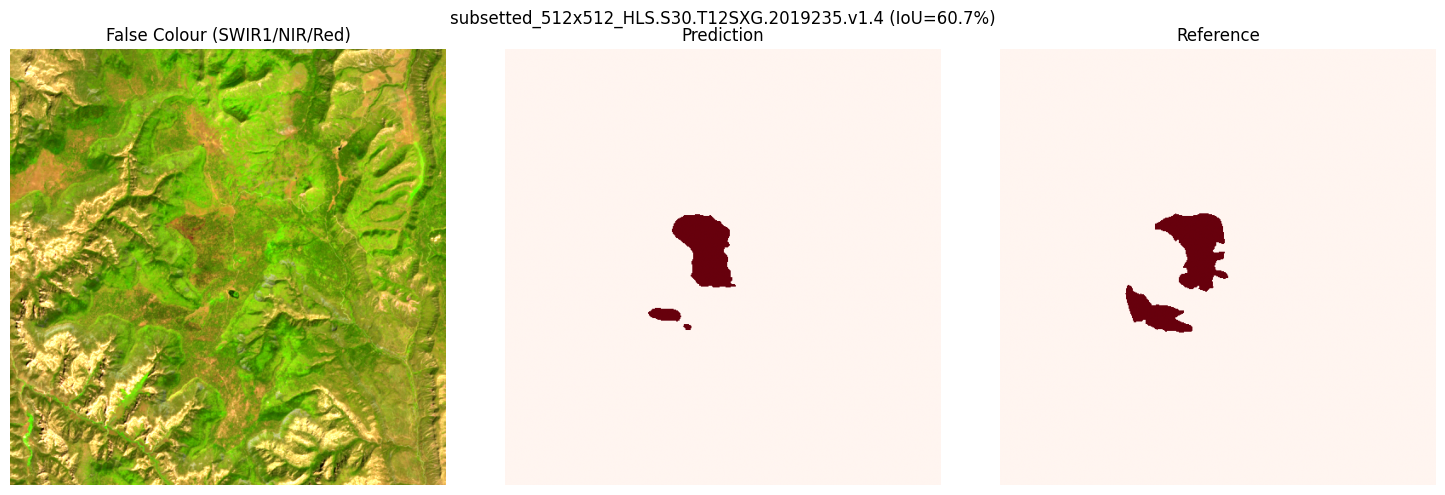

2026-05-28 01:41:48,026 - INFO - Found credentials in environment variables.


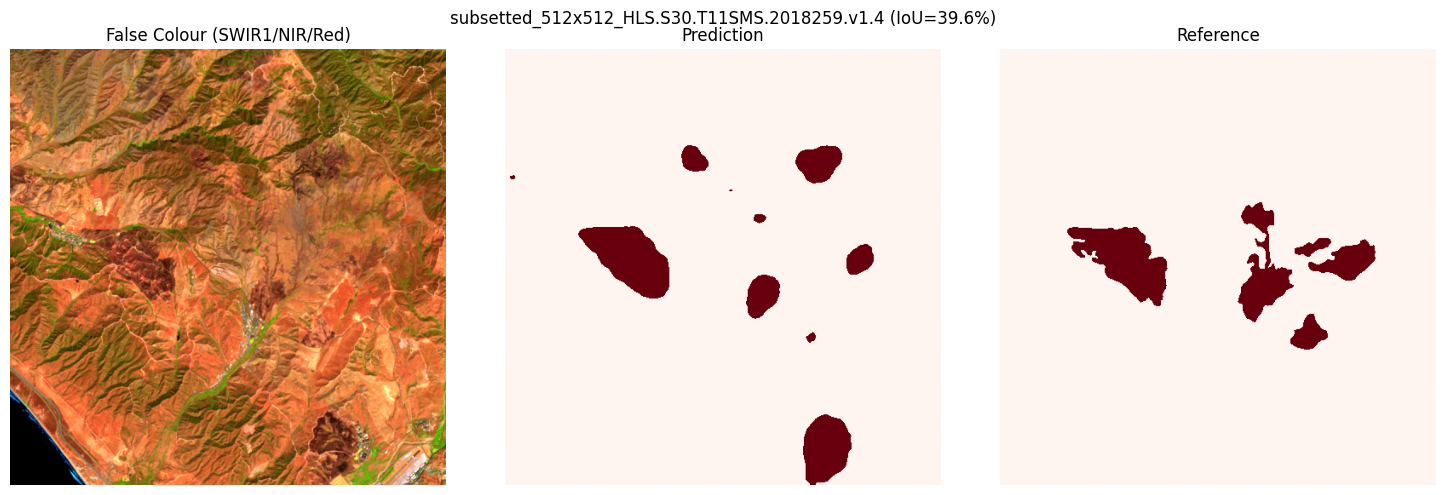

In [6]:
# Show best and worst predictions
from modules.visualisation import plot_prediction_comparison

if SHOW_VISUALISATIONS and predictions:
    bw = find_best_worst_chips(results['per_chip'], n=3)

    print("Best predictions:")
    for idx in bw['best']:
        chip_name = splits['test'][idx]
        img_path, _ = get_chip_paths(dataset_dir, chip_name)
        data, _ = load_scene(img_path)
        plot_prediction_comparison(
            data, predictions[idx], reference=targets[idx],
            title=f"{chip_name} (IoU={results['per_chip'][idx]['iou_burned']:.1%})"
        )

    print("\nWorst predictions:")
    for idx in bw['worst']:
        chip_name = splits['test'][idx]
        img_path, _ = get_chip_paths(dataset_dir, chip_name)
        data, _ = load_scene(img_path)
        plot_prediction_comparison(
            data, predictions[idx], reference=targets[idx],
            title=f"{chip_name} (IoU={results['per_chip'][idx]['iou_burned']:.1%})"
        )

**Validation:**
- Quick test: IoU > 50% confirms pipeline works.
- Full run: IoU ≥ 85% (benchmark: 87.5%).

**Stop if:** IoU < 80% (full mode). All predictions same class.

---
## Milestone 5: Inference on a New Fire Event

Apply the fine-tuned model to an HLS scene from a fire not in the training set.

2026-05-28 01:45:25,216 - INFO - Found credentials in environment variables.


2026-05-28 01:45:25,290 - INFO - Found credentials in environment variables.


Saved prediction to output/burn_scar_prediction.tif


2026-05-28 01:45:25,403 - INFO - Found credentials in environment variables.


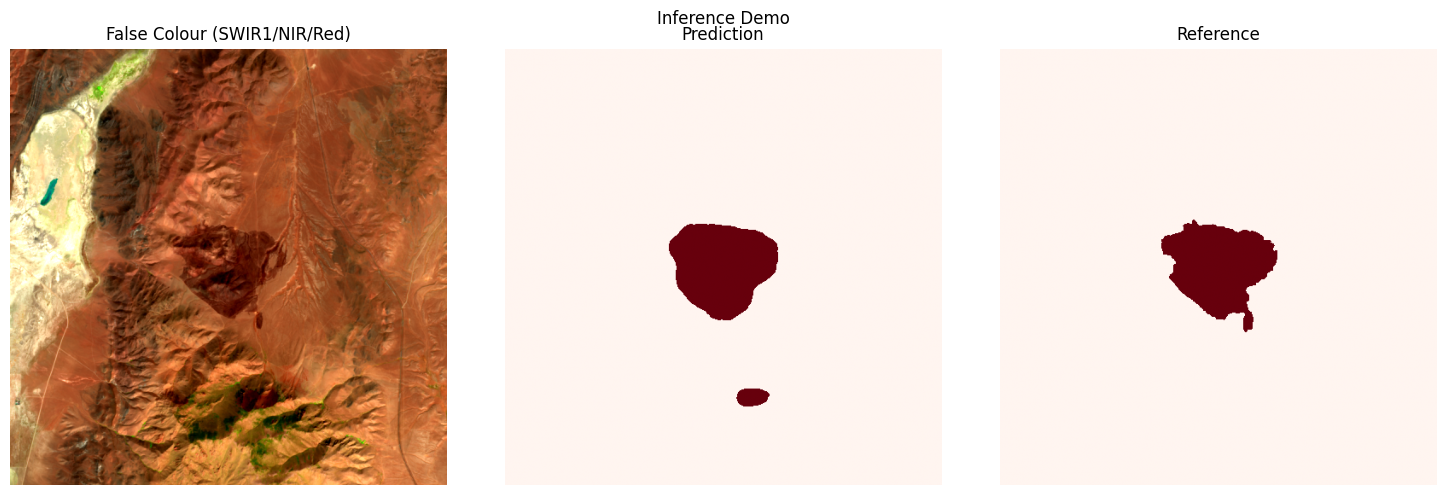

In [7]:
if RUN_INFERENCE and predictions:
    # Demo: use a test chip as stand-in for a "new" event
    # In practice, replace with a downloaded HLS scene from a recent fire
    demo_chip = splits['test'][0]
    img_path, mask_path = get_chip_paths(dataset_dir, demo_chip)
    data, meta = load_scene(img_path)
    data_norm = normalise_scene(data)
    pred = predict(model, data_norm)

    # Save as GeoTIFF
    from modules.inference import save_geotiff
    output_tif = OUTPUT_DIR / "burn_scar_prediction.tif"
    save_geotiff(pred, output_tif, crs=meta['crs'], transform=meta['transform'])

    # Visualise
    if SHOW_VISUALISATIONS:
        with rasterio.open(mask_path) as src:
            ref = src.read(1)
        plot_prediction_comparison(data, pred, reference=ref, title="Inference Demo")
else:
    print("Skipping inference.")

**Validation:** Predicted burn scar should correspond to dark patches in the false-colour composite and broadly match the reference perimeter.

**Stop if:** No burned pixels predicted. Entire scene classified as burned. Burn patches in water/urban areas.

---
## Summary

This notebook demonstrated the complete Prithvi-EO-2.0 fine-tuning workflow:
1. ✅ Dataset download and verification
2. ✅ Environment setup and config validation
3. ✅ Model fine-tuning with TerraTorch
4. ✅ Test set evaluation against benchmark
5. ✅ Inference on new imagery

**Next steps:**
- Set `QUICK_TEST = False` and re-run for full benchmark reproduction
- Download a real post-fire HLS scene for Milestone 5
- Experiment with hyperparameters (learning rate, decoder architecture)